### Módulo 3 - Desafío 5
## Inferencia e hipótesis

En este desafío validaremos nuestros conocimientos de estadística inferencial. Para lograrlo realizaremos inferencias y pruebas de hipótesis a partir de la base de datos earnings.csv

Podemos registrar muchas características de una persona, y buscar ver si algunas influyen o no en otras.

In [1]:
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(10) # para reproducibilidad
df = pd.read_csv('earnings.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   height            1816 non-null   int64  
 1   weight            1789 non-null   float64
 2   male              1816 non-null   int64  
 3   earn              1816 non-null   float64
 4   earnk             1816 non-null   float64
 5   ethnicity         1816 non-null   object 
 6   education         1814 non-null   float64
 7   mother_education  1572 non-null   float64
 8   father_education  1521 non-null   float64
 9   walk              1816 non-null   int64  
 10  exercise          1816 non-null   int64  
 11  smokenow          1815 non-null   float64
 12  tense             1815 non-null   float64
 13  angry             1815 non-null   float64
 14  age               1816 non-null   int64  
dtypes: float64(9), int64(5), object(1)
memory usage: 212.9+ KB


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
height,1816.0,66.568833,3.831822,57.0,64.0,66.0,69.25,82.0
weight,1789.0,156.305198,34.617059,80.0,130.0,150.0,180.00,342.0
male,1816.0,0.371696,0.483391,0.0,0.0,0.0,1.00,1.0
earn,1816.0,21147.296256,22531.765123,0.0,6000.0,16000.0,27000.00,400000.0
earnk,1816.0,21.147296,22.531765,0.0,6.0,16.0,27.00,400.0
education,1814.0,13.235391,2.556638,2.0,12.0,12.0,15.00,18.0
mother_education,1572.0,13.608779,3.219372,3.0,12.0,13.0,16.00,99.0
father_education,1521.0,13.652202,3.250811,3.0,12.0,13.0,16.00,99.0
walk,1816.0,5.303414,2.601104,1.0,3.0,6.0,8.00,8.0
exercise,1816.0,3.049009,2.316385,1.0,1.0,2.0,5.00,7.0


In [3]:
df.head()

,height,weight,male,earn,earnk,ethnicity,education,mother_education,father_education,walk,exercise,smokenow,tense,angry,age
0,74,210.0,1,50000.0,50.0,White,16.0,16.0,16.0,3,3,2.0,0.0,0.0,45
1,66,125.0,0,60000.0,60.0,White,16.0,16.0,16.0,6,5,1.0,0.0,0.0,58
2,64,126.0,0,30000.0,30.0,White,16.0,16.0,16.0,8,1,2.0,1.0,1.0,29
3,65,200.0,0,25000.0,25.0,White,17.0,17.0,NaN,8,1,2.0,0.0,0.0,57
4,63,110.0,0,50000.0,50.0,Other,16.0,16.0,16.0,5,6,2.0,0.0,0.0,91


### Pregunta 1
Considerando las variables **earn, height y age**, vamos a suponer que nuestro dataset fuera una población completa (Prepara los datos adecuadamente)
___


In [4]:
df[['earn', 'height', 'age']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   earn    1816 non-null   float64
 1   height  1816 non-null   int64  
 2   age     1816 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 42.7 KB


Vemos que no hay nulos en ninguna de las 3 columnas.

#### Paso a
Realiza 12 pruebas (4 por cada variable) con muestras de tamaño n = 25, en cada caso, con niveles de significancia diferentes pero inferiores a $0,1$ para confirmar o rechazar las siguientes hipótesis considerando las alternativas.
Crea para ello una fórmula que reciba los parámetros adecuados y responda *"con nivel de confianza del ...%, se acepta la hipótesis nula/alternativa"*.

In [5]:
# Definimos la función para realizar las pruebas con muestras de tamaño n=25 y determinar si rechazamos o no la hipótesis alternativa
def test_hipotesis(column, hipotesis_mean, alternative='two-sided'):
    # Tomamos una muestra aleatoria de tamaño n=25
    muestra = np.random.choice(df[column].dropna(), size=25, replace=False)
    # Nivel de significancia aleatorio inferior a 0.09
    significance_level = round(np.random.uniform(0.01, 0.09), 2)
    
    # Realizamos la prueba
    t_stat, p_value = stats.ttest_1samp(muestra, hipotesis_mean, alternative=alternative)

    alternative_text = {
        'two-sided': '!=',
        'less': '<',
        'greater': '>'
    }
    # Determinamos si rechazamos o no la hipótesis alternativa
    if p_value < significance_level:
        resultado = "se rechaza la hipótesis nula (hipótesis alternativa: media " + alternative_text[alternative] + f" {hipotesis_mean})"
        hipotesis_result = False
    else:
        resultado = "se acepta la hipótesis nula"
        hipotesis_result = True


    print(f"Con nivel de confianza del {(1-significance_level)*100}%, {resultado} para la variable {column} con media hipotética {hipotesis_mean}.")
    print(f"p-valor: {p_value:.4f}, t-stat: {t_stat:.4f}")
    return hipotesis_mean, hipotesis_result, alternative_text[alternative]

In [6]:
# Preparamos nuestras hipótesis por columna
hipotesis = {
    'alternative': ['two-sided', 'two-sided', 'greater', 'less'],
    'columns': {
        'earn': [20000, 35000, 25000, 32000],
        'height': [55, 68, 63, 70],
        'age': [44, 56, 51, 62]
    }
}

hipotesis_results = {
    'earn': {},
    'height': {},
    'age': {}
}

In [7]:
for col in hipotesis['columns']:
    for i in range(4):
        h, hipotesis_result, h_alternative = test_hipotesis(
            column=col,
            hipotesis_mean=hipotesis['columns'][col][i],
            alternative=hipotesis['alternative'][i]
        )
        hipotesis_results[col][f'test_{i+1}'] = {
            'hipotesis': h,
            'hipotesis_aceptada': hipotesis_result,
            'alternative': h_alternative
        }
    print("\n")

Con nivel de confianza del 97.0%, se acepta la hipótesis nula para la variable earn con media hipotética 20000.
p-valor: 0.0398, t-stat: -2.1738
Con nivel de confianza del 92.0%, se rechaza la hipótesis nula (hipótesis alternativa: media != 35000) para la variable earn con media hipotética 35000.
p-valor: 0.0001, t-stat: -4.6426
Con nivel de confianza del 95.0%, se acepta la hipótesis nula para la variable earn con media hipotética 25000.
p-valor: 0.2618, t-stat: 0.6474
Con nivel de confianza del 92.0%, se rechaza la hipótesis nula (hipótesis alternativa: media < 32000) para la variable earn con media hipotética 32000.
p-valor: 0.0562, t-stat: -1.6480


Con nivel de confianza del 97.0%, se rechaza la hipótesis nula (hipótesis alternativa: media != 55) para la variable height con media hipotética 55.
p-valor: 0.0000, t-stat: 18.5086
Con nivel de confianza del 95.0%, se rechaza la hipótesis nula (hipótesis alternativa: media != 68) para la variable height con media hipotética 68.
p-valor

#### Paso b
Calcula la media poblacional para cada variable. ¿Son correctos los resultados obtenidos por tus pruebas?

In [8]:

media_poblacional_earn = np.mean(df['earn'])
media_poblacional_height = np.mean(df['height'])
media_poblacional_age = np.mean(df['age'])

print(f"Media poblacional de earn: {media_poblacional_earn:.2f}")
print(f"Media poblacional de height: {media_poblacional_height:.2f}")
print(f"Media poblacional de age: {media_poblacional_age:.2f}")


Media poblacional de earn: 21147.30
Media poblacional de height: 66.57
Media poblacional de age: 42.93


In [9]:
for col in hipotesis_results:
    print(f"\nResultados para la variable {col}:")
    mean = {
        'earn': media_poblacional_earn,
        'height': media_poblacional_height,
        'age': media_poblacional_age
    }[col]
    for test, result in hipotesis_results[col].items():
        print(f"  {test}: Hipótesis = {result['hipotesis']:.2f}, Media poblacional = {mean:.2f} Hipótesis nula aceptada = {result['hipotesis_aceptada']}")
        if (not result['hipotesis_aceptada']):
            print(f"    (La media poblacional {mean:.2f} es {result['alternative']} que la hipótesis {result['hipotesis']:.2f})")


Resultados para la variable earn:
  test_1: Hipótesis = 20000.00, Media poblacional = 21147.30 Hipótesis nula aceptada = True
  test_2: Hipótesis = 35000.00, Media poblacional = 21147.30 Hipótesis nula aceptada = False
    (La media poblacional 21147.30 es != que la hipótesis 35000.00)
  test_3: Hipótesis = 25000.00, Media poblacional = 21147.30 Hipótesis nula aceptada = True
  test_4: Hipótesis = 32000.00, Media poblacional = 21147.30 Hipótesis nula aceptada = False
    (La media poblacional 21147.30 es < que la hipótesis 32000.00)

Resultados para la variable height:
  test_1: Hipótesis = 55.00, Media poblacional = 66.57 Hipótesis nula aceptada = False
    (La media poblacional 66.57 es != que la hipótesis 55.00)
  test_2: Hipótesis = 68.00, Media poblacional = 66.57 Hipótesis nula aceptada = False
    (La media poblacional 66.57 es != que la hipótesis 68.00)
  test_3: Hipótesis = 63.00, Media poblacional = 66.57 Hipótesis nula aceptada = False
    (La media poblacional 66.57 es > q

Ya que asignamos una semilla para numpy al principio del código, los resultados de los experimentos serán consistentes en cada ejecución. Con esto, podemos analizar los resultados sin preocuparnos de la muestra o de los niveles de significancia.

Podemos ver que para las hipótesis nulas aceptadas para la variable **'earn'** , tanto las hipótesis del test_1 como del test_3 se encuentran a una distancia aceptable de la media poblacional. Las hipótesis rechazadas fueron correctamente rechazadas ya que $35000$ y $32000$ están suficientemente alejadas de la media poblacional ($21147.30$).

Para las hipótesis de la variable **'height'** se rechazaron todas las hipótesis, lo que puede ser correcto para significancias muy pequeñas. En particular, las hipótesis alternativas del test_2 (mean != $68$) y del test_3 (mean > $63$) se encuentran lo suficientemente cerca de la media poblacional ($66.57$) como para haberlas rechazado.

Por último, las hipótesis nulas rechazadas de la variable **'age'** fueron correctamente rechazadas, ya que las hipótesis están lejos de la media poblaciona. Por otro lado, la hipótesis nula del test_1 fue correctamente aceptada, mientras que la del test_3 se puede considerar erróneamente aceptada pues la hipótesis de media $51$ esta lejos de la media poblacional con valor $42.93$.

### Pregunta 2
Crea una función que estime la proporción de hombres en el dataset, considerando una muestra de 50 individuos, con niveles de significancia de $0,05$ y $0,01$. Escribe con palabras tus resultados al ejecutar la función e interpreta. Compara con la proporción real.

In [10]:
# definimos la función de la propocion
def proportion(df, column, category):
    total = df.shape[0]
    subset = df[df[column] == category]
    subTotal = subset.shape[0]
    return subTotal/total

proportion(df, 'male', 1)

0.3716960352422907

In [11]:
# Ahora escribimos nuestra función para calcular en torno a una muestra
def sample_proportion(df, column, category, significance_level, n_muestras=50):
    muestra = np.random.choice(df[column].dropna(), size=n_muestras, replace=False)
    n = muestra.shape[0]
    n_category = muestra[muestra == category].sum()
    proporcion_muestra = n_category / n

    intervalo_confianza = sm.stats.proportion_confint(n_category, n, alpha=significance_level)
    print(f"Nivel de confianza: {(1-significance_level)*100}%")
    print(f"Proporción muestral de hombres: {proporcion_muestra:.2f}")
    print(f"Intervalo de confianza: {intervalo_confianza[0]:.2f} a {intervalo_confianza[1]:.2f}")
    print(f"Proporción real: {proportion(df, column, 1):.4f}\n")


sample_proportion(df, 'male', 1, 0.05, n_muestras=50)
sample_proportion(df, 'male', 1, 0.01, n_muestras=50)

Nivel de confianza: 95.0%
Proporción muestral de hombres: 0.42
Intervalo de confianza: 0.28 a 0.56
Proporción real: 0.3717

Nivel de confianza: 99.0%
Proporción muestral de hombres: 0.46
Intervalo de confianza: 0.28 a 0.64
Proporción real: 0.3717



En base a estos resultados podemos decir lo siguiente:
- Podemos afirmar que:
    - la proporción real de hombres es de un 37% (considerando el dataset como población)
    - tenemos un 95% de confianza de que la proporción de hombres en la población se encuentra entre un 28% y un 56%, mientras que la proporción muestral de hombres es del 42%
    - tenemos un 99% de confianza de que la proporción de hombres en la población se encuentra entre un 28% y un 64%, mientras que la proporción muestral de hombres es del 46%
- Nuestra proporción real está dentro de ambos intervalos, lo que valida nuestro método de estimación.

### Pregunta 3
Considerando el dataset como una muestra, verifica si el género (male=1 significa 'hombre') influye sobre el sueldo "earn" de las personas. Explica y justifica tu procedimiento.
___
Para esto, realizaremos los siguientes pasos:
- Separaremos los datos de ingresos en hombres y mujeres
- Definimos la hipótesis como:
    - $H_0$: No hay diferencia entre los sueldos de hombres y mujeres
    - $H_1$: Hay diferencia entre los sueldos de hombres y mujeres
- Realizamos una prueba t de muestras independientes
- Asignamos un nivel de confianza del $95\%$, comparamos con el resultado de la prueba p_value
- Evaluamos


In [12]:
# Obtenemos los ingresos por género
earn_hombres = df[df['male'] == 1]['earn'].dropna()
earn_mujeres = df[df['male'] == 0]['earn'].dropna()

# Realizamos la prueba t de muestras independientes
t_stat, p_value = stats.ttest_ind(earn_hombres, earn_mujeres, equal_var=False)
significance_level = 0.05
if p_value < significance_level:
    print(f"Con un nivel de confianza del {(1 - significance_level)*100}%, se rechaza la hipótesis nula:\n hay diferencia entre los ingresos de hombres y mujeres.")
else:
    print(f"Con un nivel de confianza del {(1 - significance_level)*100}%, se acepta la hipótesis nula:\n no hay diferencia entre los ingresos de hombres y mujeres.")

print(f"p-valor: {p_value:.4f}, t-stat: {t_stat:.4f}")


Con un nivel de confianza del 95.0%, se rechaza la hipótesis nula:
 hay diferencia entre los ingresos de hombres y mujeres.
p-valor: 0.0000, t-stat: 11.8646


Podemos revisar las medias de cada grupo para verificar

In [13]:
print("Promedio ingresos hombres:", earn_hombres.mean())
print("Promedio ingresos mujeres:", earn_mujeres.mean())

Promedio ingresos hombres: 30105.17925925926
Promedio ingresos mujeres: 15847.935144609992


Y en efecto vemos una diferencia bastante grande entre ambos promedios, por lo que es correcto rechazar la hipótesis nula. Si lo vemos gráficamente:

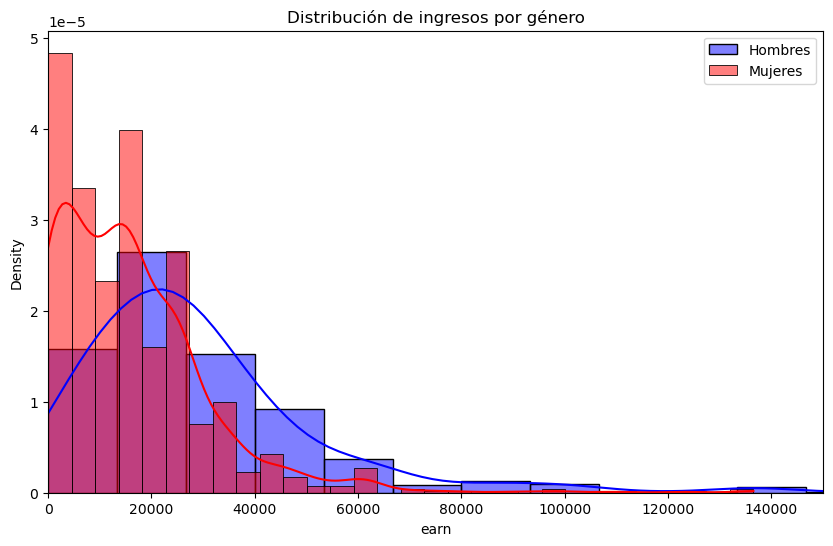

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(earn_hombres, color='blue', label='Hombres', kde=True, stat="density", bins=30)
sns.histplot(earn_mujeres, color='red', label='Mujeres', kde=True, stat="density", bins=30)
plt.legend()
plt.xlim(0, 150000) # por observación
plt.title('Distribución de ingresos por género')
plt.show()

Con esto confirmamos que existen diferencias significativas entre los ingresos de hombres y mujeres en el dataset.